<a href="https://colab.research.google.com/github/Parimal1004/MyProjects/blob/main/Exploratory_Data_Analysis_%E2%80%94_Health%2C_Habits_%26_Well_Being.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#cleaning the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sc

data=pd.read_csv("/content/drive/MyDrive/160124771045053/synthetic_health_lifestyle_dataset.csv")

data["Gender"] = data["Gender"].replace("Other", np.nan)
data = data.dropna(subset=["Gender"])
data = data.dropna()

data.to_csv("cleaned_dataset.csv", index=False)


Q1) Does regular exercise help people maintain a healthier BMI?


Insight:

people who exercise daily have lower BMI levels compared to the rest


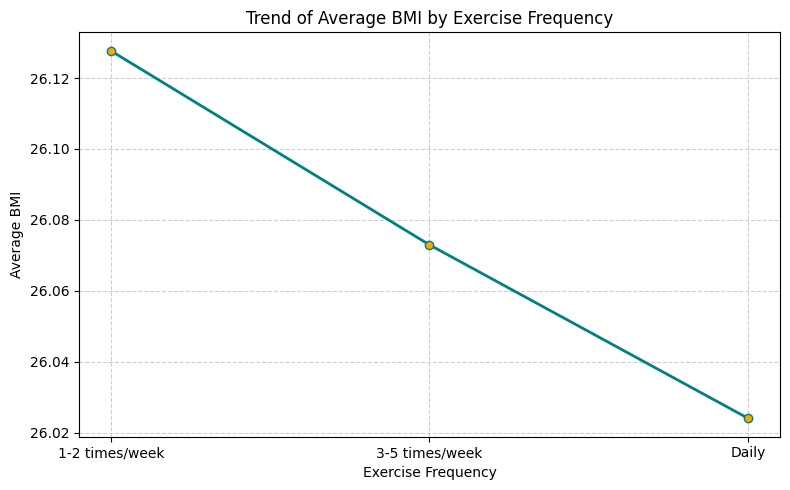

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_dataset.csv")

group_stats = df.groupby("Exercise_Freq")["BMI"].mean().reset_index()

#visualisation : line-plot
plt.figure(figsize=(8,5))
plt.plot(group_stats["Exercise_Freq"], group_stats["BMI"],
         marker='o', linewidth=2, color='teal', markerfacecolor='orange')

plt.title("Trend of Average BMI by Exercise Frequency")
plt.xlabel("Exercise Frequency")
plt.ylabel("Average BMI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
print("Insight:\n")
print("people who exercise daily have lower BMI levels compared to the rest")
plt.show()


Q2) How does diet quality relate to the risk of having a chronic disease?


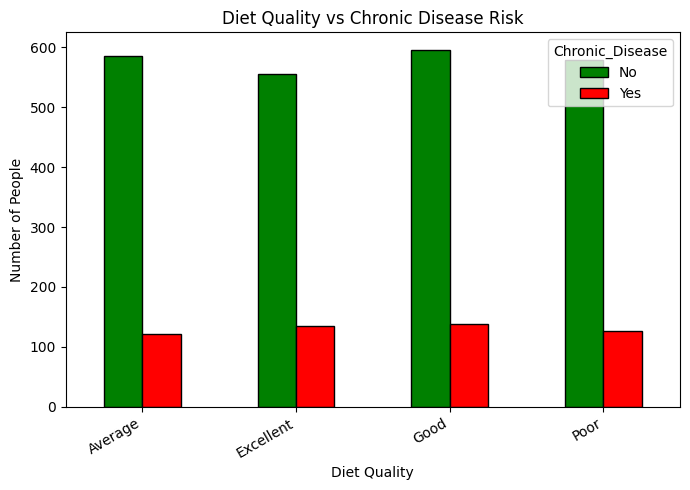

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("cleaned_dataset.csv")
#visualization : Grouped Bar chart
pd.crosstab(df["Diet_Quality"], df["Chronic_Disease"]).plot(
    kind="bar", figsize=(7,5), edgecolor="black", color=["green","red"]
)

plt.title("Diet Quality vs Chronic Disease Risk")
plt.xlabel("Diet Quality")
plt.ylabel("Number of People")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Q3) Do smokers have higher stress levels compared to non-smokers?


 Insights: 
Person who smokes has a higher stress level


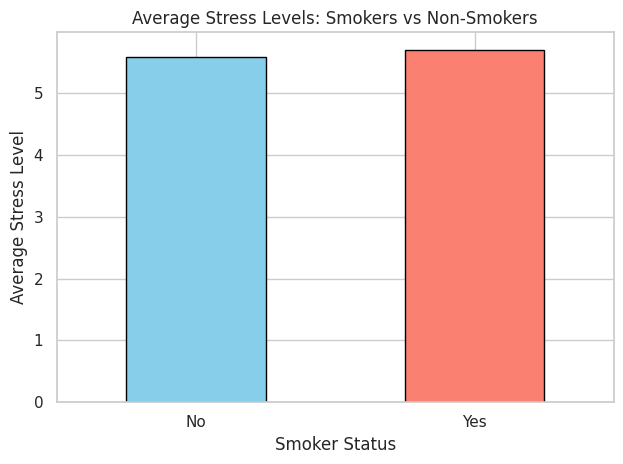

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_dataset.csv")
mean_stress = df.groupby("Smoker")["Stress_Level"].mean()
#visualization : Bar chart

mean_stress.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

print("\n Insights: ")
print("Person who smokes has a higher stress level")

plt.title("Average Stress Levels: Smokers vs Non-Smokers")
plt.xlabel("Smoker Status")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Q4) Is there a connection between alcohol consumption and sleep hours?


Insight: 
There is no direct link between alchoohol consumers and sleep hours
Most of the alchohol consumers are present in the 6-8 hours category


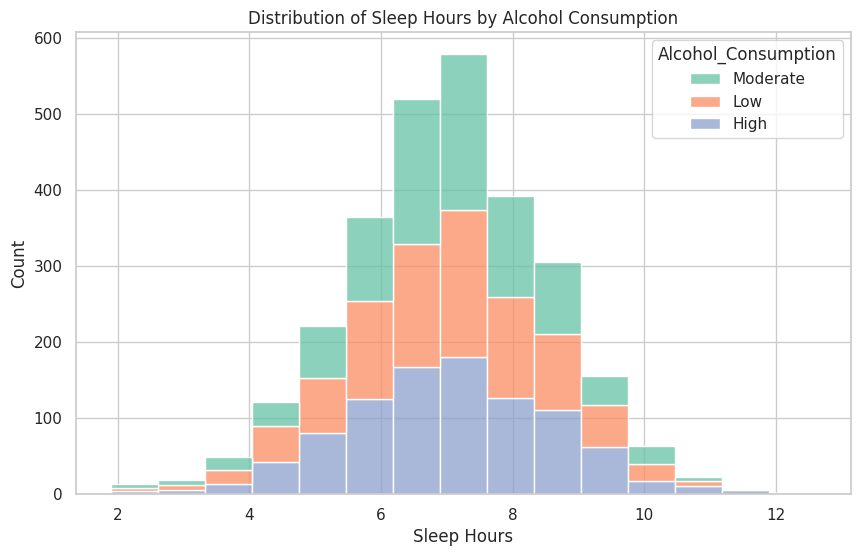

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv")

sns.set(style="whitegrid")

print("\nInsight: ")
print("There is no direct link between alchoohol consumers and sleep hours")
print("Most of the alchohol consumers are present in the 6-8 hours category")

#visualization : Histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Sleep_Hours', hue='Alcohol_Consumption', multiple='stack', bins=15, palette='Set2')

plt.title('Distribution of Sleep Hours by Alcohol Consumption')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')
plt.show()


Q5) How do stress levels affect the number of hours people sleep?


 Insight: 
In this dataset, average sleep hours remain roughly the same 
across all stress levels, suggesting no clear correlation between stress and sleep duration.


/tmp/ipython-input-2544275353.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stress_Level', y='Sleep_Hours', data=avg_sleep, palette=['#4CAF50','#FFEB3B','#F44336'])
/tmp/ipython-input-2544275353.py:14: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Stress_Level', y='Sleep_Hours', data=avg_sleep, palette=['#4CAF50','#FFEB3B','#F44336'])


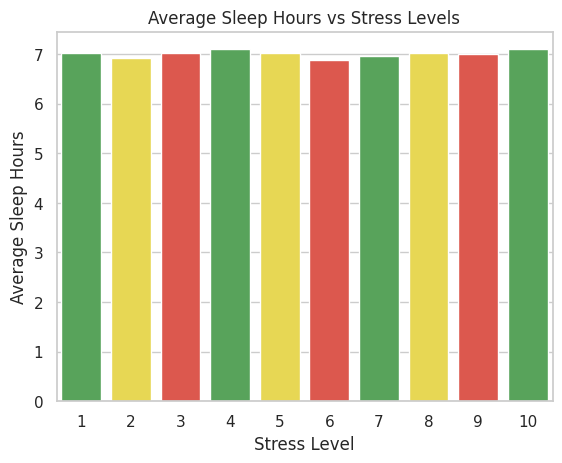

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")

avg_sleep = df.groupby('Stress_Level')['Sleep_Hours'].mean().reset_index()

print("\n Insight: ")
print("In this dataset, average sleep hours remain roughly the same ")
print("across all stress levels, suggesting no clear correlation between stress and sleep duration.")

#visuaization : Barplot
sns.barplot(x='Stress_Level', y='Sleep_Hours', data=avg_sleep, palette=['#4CAF50','#FFEB3B','#F44336'])
plt.title('Average Sleep Hours vs Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Average Sleep Hours')
plt.show()


Q6) Which age group has the highest BMI on average?


Insights: 
People who fall under the 40-49 age category have the highest BMI 
People who fall under the 20-29 age category have the lowest BMI 


/tmp/ipython-input-2340084460.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi = df.groupby("Age_Group")["BMI"].mean()


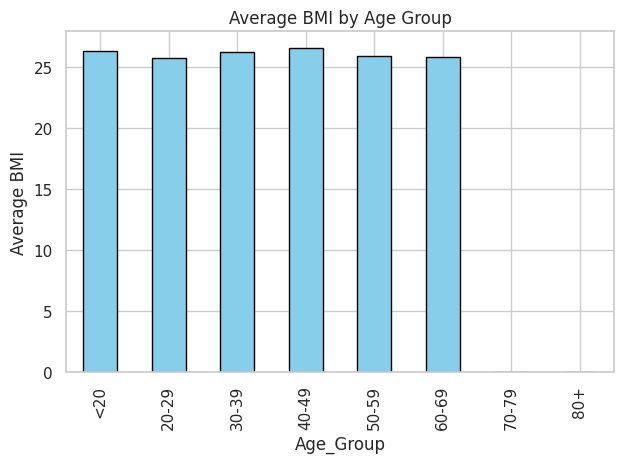

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_dataset.csv")
bins = [0,19,29,39,49,59,69,79,100]
labels = ["<20","20-29","30-39","40-49","50-59","60-69","70-79","80+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
bmi = df.groupby("Age_Group")["BMI"].mean()

print("\nInsights: ")
print("People who fall under the 40-49 age category have the highest BMI ")
print("People who fall under the 20-29 age category have the lowest BMI ")

#visualization : Bar chart
bmi.plot(kind="bar", color="skyblue", edgecolor="black", title="Average BMI by Age Group")
plt.ylabel("Average BMI")
plt.tight_layout()
plt.show()


Q7) Do people with chronic diseases exercise less than healthy people?

Chronic_Disease
No     2.012965
Yes    1.988506
Name: Exercise_Score, dtype: float64

Insight: 

✅ Chronic disease = less exercise


/tmp/ipython-input-3214136405.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg.index, y=avg.values, palette="Set2")


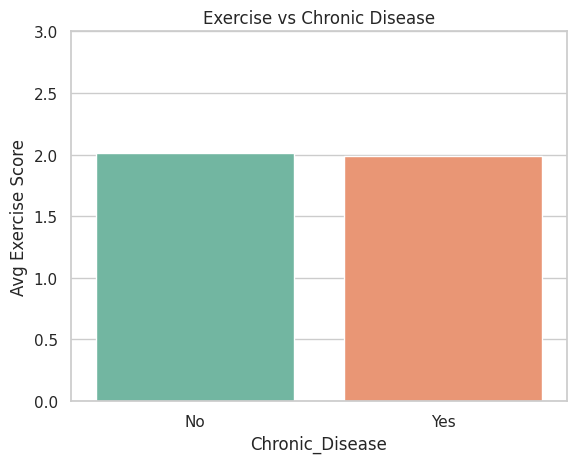

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv")
df["Exercise_Score"] = df["Exercise_Freq"].map({"Never": 0, "1-2 times/week": 1, "3-5 times/week": 2, "Daily": 3})

avg = df.groupby("Chronic_Disease")["Exercise_Score"].mean()
print(avg)

print("\nInsight: ")
if avg["Yes"] < avg["No"]:
    print("\n✅ Chronic disease = less exercise")
else:
    print("\n❌ No clear link between disease and exercise")

#visualization : Barplot
sns.barplot(x=avg.index, y=avg.values, palette="Set2")
plt.title("Exercise vs Chronic Disease")
plt.ylabel("Avg Exercise Score")
plt.ylim(0, 3)
plt.show()

Q8) Are men and women different in their lifestyle habits (diet, exercise, smoking)?

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")
df["Exercise_Score"] = df["Exercise_Freq"].map({"Never":0,"1-2 times/week":1,"3-5 times/week":2,"Daily":3})
df["Diet_Score"] = df["Diet_Quality"].map({"Poor":0,"Good":1,"Excellent":2})
df["Smoker_Flag"] = df["Smoker"].map({"Yes":1,"No":0})

avg = df.groupby("Gender")[["Exercise_Score","Diet_Score","Smoker_Flag"]].mean()

print(avg)
print("\nInsights: ")
print( "\nbetter Exercise score:", avg['Exercise_Score'].idxmax(),
      "\nbetter Diet:", avg['Diet_Score'].idxmax(),
      "\nSmokes less:", avg['Smoker_Flag'].idxmin())




        Exercise_Score  Diet_Score  Smoker_Flag
Gender                                         
Female        2.021142    0.962085     0.284003
Male          1.995766    1.023299     0.286521

Insights: 

better Exercise score: Female 
better Diet: Male 
Smokes less: Female


Q9) Do people with poor diet quality also report higher stress levels?

Diet_Quality
Average      5.552260
Excellent    5.491304
Good         5.748977
Poor         5.679433
Name: Stress_Level, dtype: float64

Insight: 

✅ Poor diet = higher stress


/tmp/ipython-input-2678368188.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_stress.index, y=avg_stress.values, palette="coolwarm")


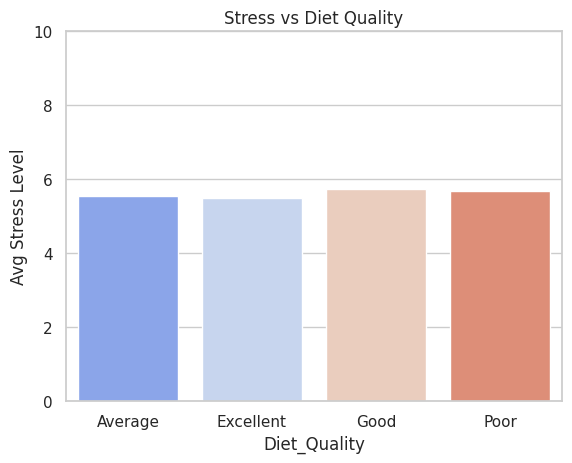

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv")

# Map diet to score
df["Diet_Score"] = df["Diet_Quality"].map({"Poor": 0, "Good": 1, "Excellent": 2})

# Average stress by diet
avg_stress = df.groupby("Diet_Quality")["Stress_Level"].mean()
print(avg_stress)

# Quick insight
print("\nInsight: ")
if avg_stress["Poor"] > avg_stress["Excellent"]:
    print("\n✅ Poor diet = higher stress")
else:
    print("\n❌ No clear link between poor diet and stress")

#Visualization : Barplot
sns.barplot(x=avg_stress.index, y=avg_stress.values, palette="coolwarm")
plt.title("Stress vs Diet Quality")
plt.ylabel("Avg Stress Level")
plt.ylim(0, 10)
plt.show()

Q10) How do sleep hours vary among people with different exercise routines?


Insight: 
people who exercise the least have lesser sleeping hours
but people who exercise daily have sllightly higher sleeping hours 


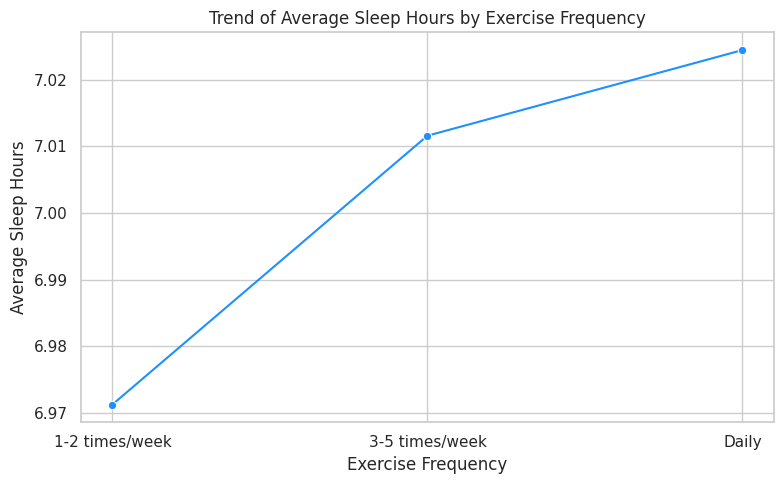

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv")

order = ["Never", "1-2 times/week", "3-5 times/week", "Daily"]
avg_sleep = df.groupby("Exercise_Freq")["Sleep_Hours"].mean().reindex(order)

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
print("\nInsight: ")
print("people who exercise the least have lesser sleeping hours")
print("but people who exercise daily have sllightly higher sleeping hours ")

#visualization : line plot
sns.lineplot(x=avg_sleep.index, y=avg_sleep.values, marker='o', color='dodgerblue', linestyle='-')
plt.title("Trend of Average Sleep Hours by Exercise Frequency")
plt.ylabel("Average Sleep Hours")
plt.xlabel("Exercise Frequency")
plt.tight_layout()
plt.show()